# Router 1: common 102-string and 160-string test predictions

Load the Router 1 inference outputs and construct one dataframe containing the predictions for events shared by the 102-string and 160-string test sets.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


results_dir = Path(
    "/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC"
)
router_directory = "category1_isMuonCC"
detector_strings = ("102", "160")
id_columns = ["pid", "is_CC", "RunID", "SubrunID", "EventID", "SubEventID"]

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/project/def-nahee/kbas/.venv_try/lib64/python3.9/site-packages/traitlets/traitlets.py", line 651, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/project/def-nahee/kbas/.venv_try/lib64/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/project/def-nahee/kbas/.venv_try/lib64/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/project/def-nahee/kbas/.venv_try/lib64/python3.9/site-packages/traitlets/traitlets.py", line 706, in __get__
    return self.get(obj, cls)  # type:ignore[return-value]
  File "/project/def-nahee/kbas/.venv_try/lib64/python3.9/site-packages/traitlets/traitlets.py", line 668, in get
    value = self._vali

In [2]:
router1_frames = {}

for detector in detector_strings:
    prediction_file = (
        results_dir
        / f"{detector}_string_emax1e6"
        / "inference"
        / router_directory
        / "baseline"
        / "inference"
        / "inference_predictions.csv"
    )

    frame = pd.read_csv(prediction_file)
    frame[id_columns] = frame[id_columns].astype(np.int64)

    if frame.duplicated(id_columns).any():
        raise ValueError(f"Duplicate physics event keys in {prediction_file}")

    router1_frames[detector] = frame
    print(f"{detector}-string Router 1 predictions: {len(frame):,} events")

102-string Router 1 predictions: 42,989 events
160-string Router 1 predictions: 53,435 events


In [3]:
prediction_columns = [
    column
    for column in router1_frames["102"].columns
    if column in ["true_classification_class", "predicted_route_class"]
    or column.startswith(("p_class_", "pred_", "residual_"))
    or column.endswith("_kappa")
]

truth_columns = [
    column
    for column in router1_frames["102"].columns
    if column not in prediction_columns
    and column not in id_columns
    and column not in ["event_key", "event_no"]
]

events_102 = pd.MultiIndex.from_frame(router1_frames["102"][id_columns])
events_160 = pd.MultiIndex.from_frame(router1_frames["160"][id_columns])
common_events = events_102.intersection(events_160)

router1_predictions = (
    router1_frames["102"]
    .set_index(id_columns)
    .loc[common_events, truth_columns]
    .reset_index()
)

for detector in detector_strings:
    detector_predictions = router1_frames[detector][
        id_columns + prediction_columns
    ].copy()
    detector_predictions = detector_predictions[
        pd.MultiIndex.from_frame(detector_predictions[id_columns]).isin(common_events)
    ]
    detector_predictions = detector_predictions.rename(
        columns={
            column: f"{detector}_{column}"
            for column in prediction_columns
        }
    )

    router1_predictions = router1_predictions.merge(
        detector_predictions,
        on=id_columns,
        how="inner",
        validate="one_to_one",
    )

router1_predictions = router1_predictions.sort_values(id_columns).reset_index(drop=True)

print(f"Common Router 1 test events: {len(common_events):,}")
print(f"Combined dataframe shape: {router1_predictions.shape}")
display(router1_predictions.head())

Common Router 1 test events: 42,989
Combined dataframe shape: (42989, 63)


,pid,is_CC,RunID,SubrunID,EventID,SubEventID,category1_isMuonCC,category2_tauCC_others_muonCC,category_3_contains_muon,position_x,...,160_pred_log10_energy,160_pred_zenith_radian,160_pred_zenith_degree,160_residual_zenith_degree,160_zenith_kappa,160_pred_azimuth_radian,160_pred_azimuth_degree,160_residual_azimuth_degree,160_azimuth_kappa,160_pred_azimuth_degree_signed
0,-16,1,3,4294967295,131,0,0.0,0.0,1.0,-684.529812,...,3.866932,1.087027,62.282036,-0.699869,98.539170,1.858602,106.490020,-0.589240,94.572235,106.490040
1,-16,1,13,4294967295,163,0,0.0,0.0,0.0,-583.062130,...,3.671592,0.744914,42.680400,4.969823,36.327896,1.460593,83.685814,7.404444,17.127870,83.685814
2,-16,1,16,4294967295,114,0,0.0,0.0,0.0,-496.208479,...,3.329737,1.294035,74.142770,-3.904102,19.708990,2.158025,123.645740,-47.926890,0.883530,123.645730
3,-16,1,16,4294967295,196,0,0.0,0.0,1.0,482.733734,...,2.281000,2.184639,125.170600,9.725028,10.299860,5.929508,339.735800,93.343346,0.906780,-20.264200
4,-16,1,20,4294967295,149,0,0.0,0.0,1.0,449.928411,...,3.272910,1.661847,95.216790,50.604973,7.932799,5.122619,293.504430,-5.068164,5.245228,-66.495560


## Opening angle

The opening angle between the true and reconstructed directions is defined by

$$
\Delta\Psi = \arccos\!\left(\hat{u}_{\mathrm{true}}\cdot\hat{u}_{\mathrm{reco}}\right).
$$

Writing the two unit vectors in terms of their zenith angles $\theta$ and azimuth angles $\phi$ gives

$$
\Delta\Psi = \arccos\!\left[
\cos\theta_{\mathrm{true}}\cos\theta_{\mathrm{reco}}
+ \sin\theta_{\mathrm{true}}\sin\theta_{\mathrm{reco}}
\cos\!\left(\phi_{\mathrm{true}}-\phi_{\mathrm{reco}}\right)
\right].
$$

The calculation is performed using angles in radians, and the resulting opening angles are stored in degrees.

In [4]:
true_zenith = router1_predictions["true_zenith_radian"].to_numpy()
true_azimuth = router1_predictions["true_azimuth_radian"].to_numpy()

for detector in detector_strings:
    predicted_zenith = router1_predictions[
        f"{detector}_pred_zenith_radian"
    ].to_numpy()
    predicted_azimuth = router1_predictions[
        f"{detector}_pred_azimuth_radian"
    ].to_numpy()

    cosine_opening_angle = (
        np.cos(true_zenith) * np.cos(predicted_zenith)
        + np.sin(true_zenith)
        * np.sin(predicted_zenith)
        * np.cos(true_azimuth - predicted_azimuth)
    )

    opening_angle_radian = np.arccos(
        np.clip(cosine_opening_angle, -1.0, 1.0)
    )
    router1_predictions[f"{detector}_opening_angle"] = np.degrees(
        opening_angle_radian
    )

display(
    router1_predictions[
        ["102_opening_angle", "160_opening_angle"]
    ].describe()
)

,102_opening_angle,160_opening_angle
count,42989.000000,42989.000000
mean,22.748834,18.441329
std,26.630733,23.263009
min,0.035164,0.010740
25%,5.190335,3.505930
50%,12.769840,9.902839
75%,29.625654,23.731157
max,179.296444,177.839014


## Directional-reconstruction performance

The directional performance is compared for all common Router-1 events and for four interaction categories. Neutrinos and antineutrinos are combined within each category by selecting the absolute PDG particle identifier, $|\mathrm{pid}|$. The five rows correspond to all events, Muon CC, Tau CC, Electron CC, and Electron NC, respectively.

The azimuth residual is wrapped to the principal interval $[-\pi,\pi]$,

$$
\Delta\phi=\operatorname{atan2}\!\left[\sin(\phi_{\mathrm{reco}}-\phi_{\mathrm{true}}),\cos(\phi_{\mathrm{reco}}-\phi_{\mathrm{true}})\right],
$$

and the cosine-zenith residual is defined as

$$
\Delta\cos\theta=\cos\theta_{\mathrm{reco}}-\cos\theta_{\mathrm{true}}.
$$

Their distributions are shown as unweighted kernel-density estimates. Two summaries of the opening-angle distribution are evaluated in each true-energy bin: the median, $\Delta\Psi_{50}(E)$, and the central-68\% half-width, $[Q_{84}(E)-Q_{16}(E)]/2$. The latter measures the spread between the 16th and 84th percentiles and should not be confused with the 68\% containment angle, $Q_{68}$. The lower panels show the corresponding 160-string/102-string ratios; values below unity indicate better directional resolution for the 160-string geometry.

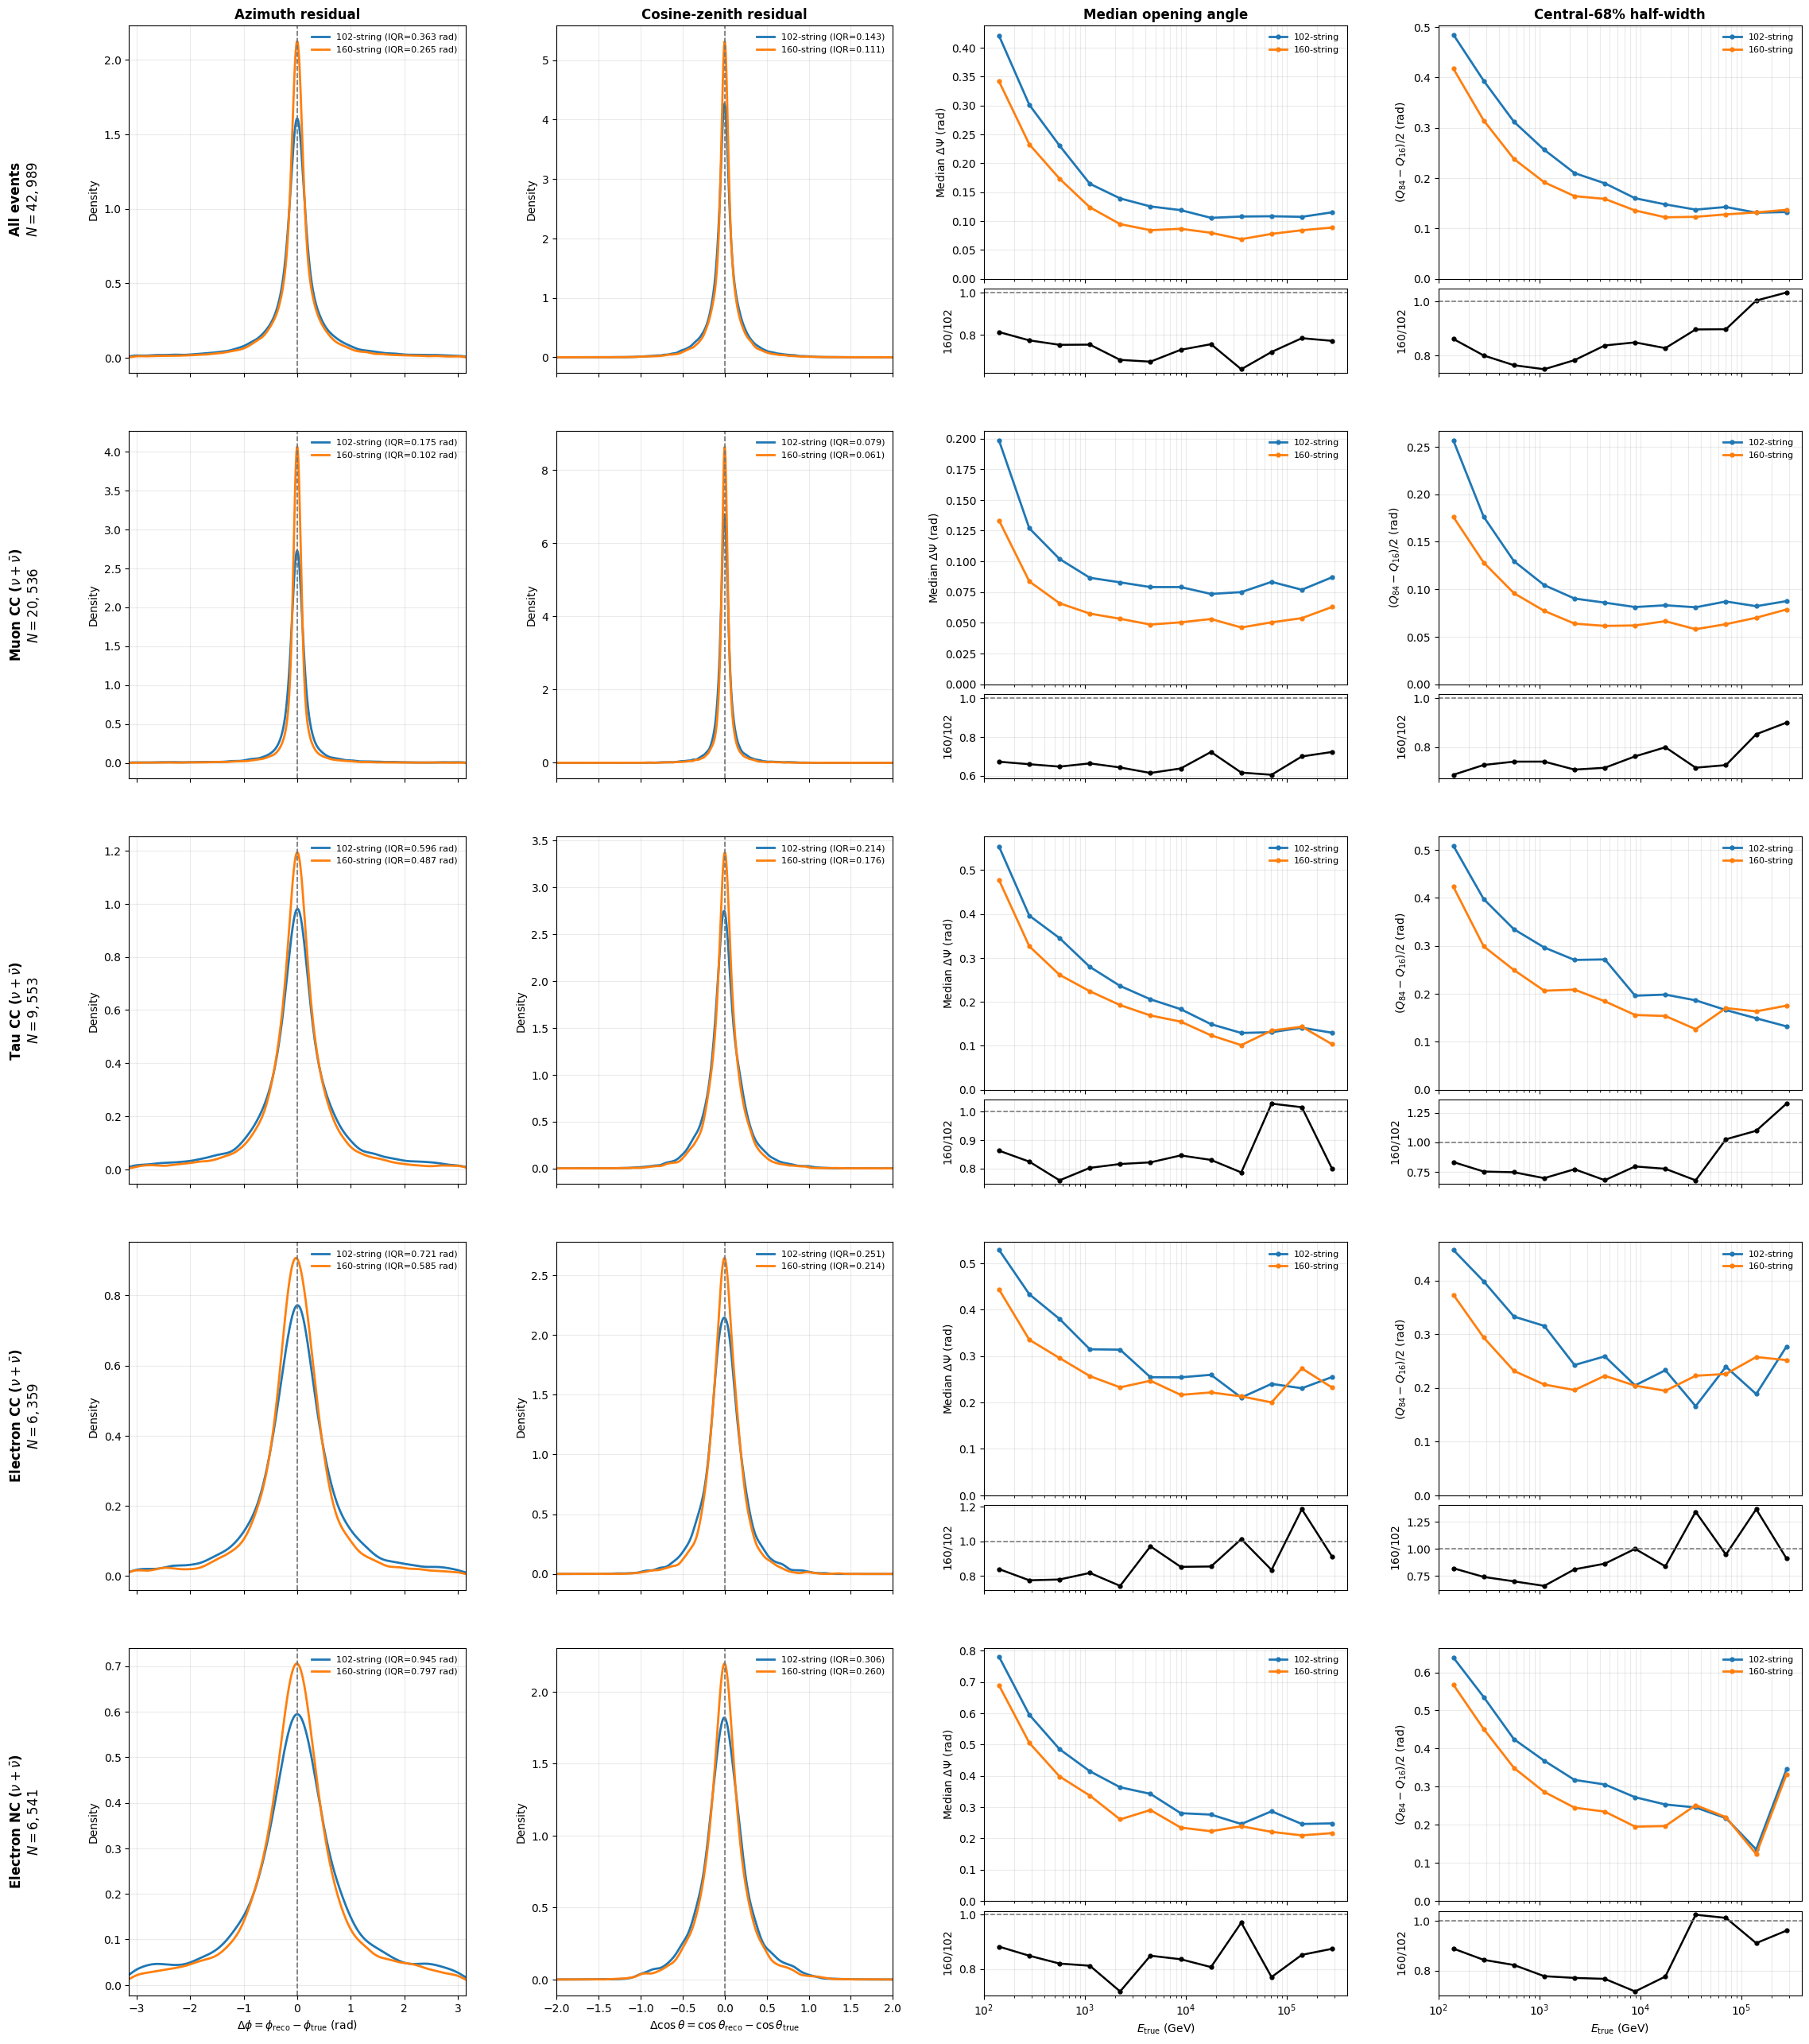

In [10]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


detector_colors = {"102": "tab:blue", "160": "tab:orange"}
category_rows = [
    ("All events", np.ones(len(router1_predictions), dtype=bool)),
    (
        r"Muon CC ($\nu+\bar{\nu}$)",
        (router1_predictions["pid"].abs() == 14)
        & (router1_predictions["is_CC"] == 1),
    ),
    (
        r"Tau CC ($\nu+\bar{\nu}$)",
        (router1_predictions["pid"].abs() == 16)
        & (router1_predictions["is_CC"] == 1),
    ),
    (
        r"Electron CC ($\nu+\bar{\nu}$)",
        (router1_predictions["pid"].abs() == 12)
        & (router1_predictions["is_CC"] == 1),
    ),
    (
        r"Electron NC ($\nu+\bar{\nu}$)",
        (router1_predictions["pid"].abs() == 12)
        & (router1_predictions["is_CC"] == 0),
    ),
]

true_azimuth = router1_predictions["true_azimuth_radian"].to_numpy()
true_zenith = router1_predictions["true_zenith_radian"].to_numpy()
true_energy = router1_predictions["true_energy"].to_numpy(dtype=float)
azimuth_grid = np.linspace(-np.pi, np.pi, 1000)
cosine_zenith_grid = np.linspace(-2.0, 2.0, 1000)
energy_bin_edges = np.logspace(2.0, 5.6, 13)
energy_bin_centers = np.sqrt(
    energy_bin_edges[:-1] * energy_bin_edges[1:]
)

# Store the residuals once; the category masks are applied below.
for detector in detector_strings:
    predicted_azimuth = router1_predictions[
        f"{detector}_pred_azimuth_radian"
    ].to_numpy()
    router1_predictions[f"{detector}_azimuth_residual_radian"] = np.arctan2(
        np.sin(predicted_azimuth - true_azimuth),
        np.cos(predicted_azimuth - true_azimuth),
    )

    predicted_zenith = router1_predictions[
        f"{detector}_pred_zenith_radian"
    ].to_numpy()
    router1_predictions[f"{detector}_cosine_zenith_residual"] = (
        np.cos(predicted_zenith) - np.cos(true_zenith)
    )

figure = plt.figure(figsize=(23.0, 27.0))
outer_grid = figure.add_gridspec(
    3 * len(category_rows),
    4,
    width_ratios=[1.0, 1.0, 1.08, 1.08],
    height_ratios=[3.0, 1.0, 0.45] * len(category_rows),
    hspace=0.08,
    wspace=0.26,
)

for row_index, (category_label, category_mask) in enumerate(category_rows):
    category_mask = np.asarray(category_mask, dtype=bool)
    main_row = 3 * row_index
    ratio_row = main_row + 1
    azimuth_axis = figure.add_subplot(
        outer_grid[main_row : ratio_row + 1, 0]
    )
    cosine_zenith_axis = figure.add_subplot(
        outer_grid[main_row : ratio_row + 1, 1]
    )
    median_axis = figure.add_subplot(outer_grid[main_row, 2])
    median_ratio_axis = figure.add_subplot(
        outer_grid[ratio_row, 2], sharex=median_axis
    )
    half_width_axis = figure.add_subplot(outer_grid[main_row, 3])
    half_width_ratio_axis = figure.add_subplot(
        outer_grid[ratio_row, 3], sharex=half_width_axis
    )

    median_by_detector = {}
    half_width_by_detector = {}

    for detector in detector_strings:
        azimuth_residual = router1_predictions[
            f"{detector}_azimuth_residual_radian"
        ].to_numpy()
        selected_azimuth = azimuth_residual[
            category_mask & np.isfinite(azimuth_residual)
        ]
        if selected_azimuth.size >= 2 and np.ptp(selected_azimuth) > 0:
            azimuth_density = gaussian_kde(selected_azimuth)(azimuth_grid)
            q25, q75 = np.quantile(selected_azimuth, [0.25, 0.75])
            azimuth_axis.plot(
                azimuth_grid,
                azimuth_density,
                color=detector_colors[detector],
                linewidth=2.0,
                label=f"{detector}-string (IQR={q75 - q25:.3f} rad)",
            )

        cosine_residual = router1_predictions[
            f"{detector}_cosine_zenith_residual"
        ].to_numpy()
        selected_cosine = cosine_residual[
            category_mask & np.isfinite(cosine_residual)
        ]
        if selected_cosine.size >= 2 and np.ptp(selected_cosine) > 0:
            cosine_density = gaussian_kde(selected_cosine)(
                cosine_zenith_grid
            )
            q25, q75 = np.quantile(selected_cosine, [0.25, 0.75])
            cosine_zenith_axis.plot(
                cosine_zenith_grid,
                cosine_density,
                color=detector_colors[detector],
                linewidth=2.0,
                label=f"{detector}-string (IQR={q75 - q25:.3f})",
            )

        opening_angle_radian = np.radians(
            router1_predictions[f"{detector}_opening_angle"].to_numpy(
                dtype=float
            )
        )
        medians = []
        half_widths = []

        for lower_edge, upper_edge in zip(
            energy_bin_edges[:-1], energy_bin_edges[1:]
        ):
            valid = (
                category_mask
                & (true_energy >= lower_edge)
                & (true_energy < upper_edge)
                & np.isfinite(opening_angle_radian)
            )
            if np.any(valid):
                selected_angles = opening_angle_radian[valid]
                medians.append(np.median(selected_angles))
                q16, q84 = np.quantile(selected_angles, [0.16, 0.84])
                half_widths.append(0.5 * (q84 - q16))
            else:
                medians.append(np.nan)
                half_widths.append(np.nan)

        medians = np.asarray(medians)
        half_widths = np.asarray(half_widths)
        median_by_detector[detector] = medians
        half_width_by_detector[detector] = half_widths

        median_axis.plot(
            energy_bin_centers,
            medians,
            color=detector_colors[detector],
            linewidth=2.0,
            marker="o",
            markersize=3.5,
            label=f"{detector}-string",
        )
        half_width_axis.plot(
            energy_bin_centers,
            half_widths,
            color=detector_colors[detector],
            linewidth=2.0,
            marker="o",
            markersize=3.5,
            label=f"{detector}-string",
        )

    median_ratio = np.divide(
        median_by_detector["160"],
        median_by_detector["102"],
        out=np.full_like(median_by_detector["160"], np.nan),
        where=median_by_detector["102"] > 0,
    )
    half_width_ratio = np.divide(
        half_width_by_detector["160"],
        half_width_by_detector["102"],
        out=np.full_like(half_width_by_detector["160"], np.nan),
        where=half_width_by_detector["102"] > 0,
    )

    median_ratio_axis.plot(
        energy_bin_centers,
        median_ratio,
        color="black",
        linewidth=1.8,
        marker="o",
        markersize=3.5,
    )
    half_width_ratio_axis.plot(
        energy_bin_centers,
        half_width_ratio,
        color="black",
        linewidth=1.8,
        marker="o",
        markersize=3.5,
    )

    azimuth_axis.axvline(
        0.0, color="0.45", linestyle="--", linewidth=1.2
    )
    cosine_zenith_axis.axvline(
        0.0, color="0.45", linestyle="--", linewidth=1.2
    )
    median_ratio_axis.axhline(
        1.0, color="0.45", linestyle="--", linewidth=1.1
    )
    half_width_ratio_axis.axhline(
        1.0, color="0.45", linestyle="--", linewidth=1.1
    )

    azimuth_axis.set_xlim(-np.pi, np.pi)
    cosine_zenith_axis.set_xlim(-2.0, 2.0)
    median_axis.set_ylim(bottom=0.0)
    half_width_axis.set_ylim(bottom=0.0)

    for energy_axis in (
        median_ratio_axis,
        half_width_ratio_axis,
    ):
        energy_axis.set_xscale("log")
        energy_axis.set_xlim(energy_bin_edges[0], energy_bin_edges[-1])
        energy_axis.set_ylabel(r"$160/102$")
        energy_axis.grid(alpha=0.25, which="both")

    azimuth_axis.set_ylabel("Density")
    cosine_zenith_axis.set_ylabel("Density")
    median_axis.set_ylabel(r"Median $\Delta\Psi$ (rad)")
    half_width_axis.set_ylabel(r"$(Q_{84}-Q_{16})/2$ (rad)")

    for main_axis in (
        azimuth_axis,
        cosine_zenith_axis,
        median_axis,
        half_width_axis,
    ):
        main_axis.grid(alpha=0.25, which="both")
        main_axis.legend(frameon=False, fontsize=8)

    azimuth_axis.annotate(
        f"{category_label}\n$N={category_mask.sum():,}$",
        xy=(-0.31, 0.5),
        xycoords="axes fraction",
        ha="center",
        va="center",
        rotation=90,
        fontsize=12,
        fontweight="bold",
    )

    if row_index == 0:
        azimuth_axis.set_title("Azimuth residual", fontweight="bold")
        cosine_zenith_axis.set_title(
            "Cosine-zenith residual", fontweight="bold"
        )
        median_axis.set_title(
            "Median opening angle", fontweight="bold"
        )
        half_width_axis.set_title(
            "Central-68% half-width", fontweight="bold"
        )

    if row_index == len(category_rows) - 1:
        azimuth_axis.set_xlabel(
            r"$\Delta\phi=\phi_{\mathrm{reco}}"
            r"-\phi_{\mathrm{true}}$ (rad)"
        )
        cosine_zenith_axis.set_xlabel(
            r"$\Delta\cos\theta=\cos\theta_{\mathrm{reco}}"
            r"-\cos\theta_{\mathrm{true}}$"
        )
        median_ratio_axis.set_xlabel(r"$E_{\mathrm{true}}$ (GeV)")
        half_width_ratio_axis.set_xlabel(r"$E_{\mathrm{true}}$ (GeV)")
    else:
        azimuth_axis.tick_params(labelbottom=False)
        cosine_zenith_axis.tick_params(labelbottom=False)
        median_ratio_axis.tick_params(labelbottom=False)
        half_width_ratio_axis.tick_params(labelbottom=False)

    median_axis.tick_params(labelbottom=False)
    half_width_axis.tick_params(labelbottom=False)

figure.subplots_adjust(
    left=0.075, right=0.99, bottom=0.04, top=0.98
)
plt.show()

## Directional performance: Muon CC versus remaining events

The same directional-performance summaries are shown for all common Router-1 events, the Muon CC subset, and its complement. The Muon CC subset contains neutrinos and antineutrinos with $|\mathrm{pid}|=14$ and $\mathrm{is\_CC}=1$. The remaining-event subset contains every event that does not satisfy this condition; the two subsets are therefore mutually exclusive and together reproduce the all-event sample.

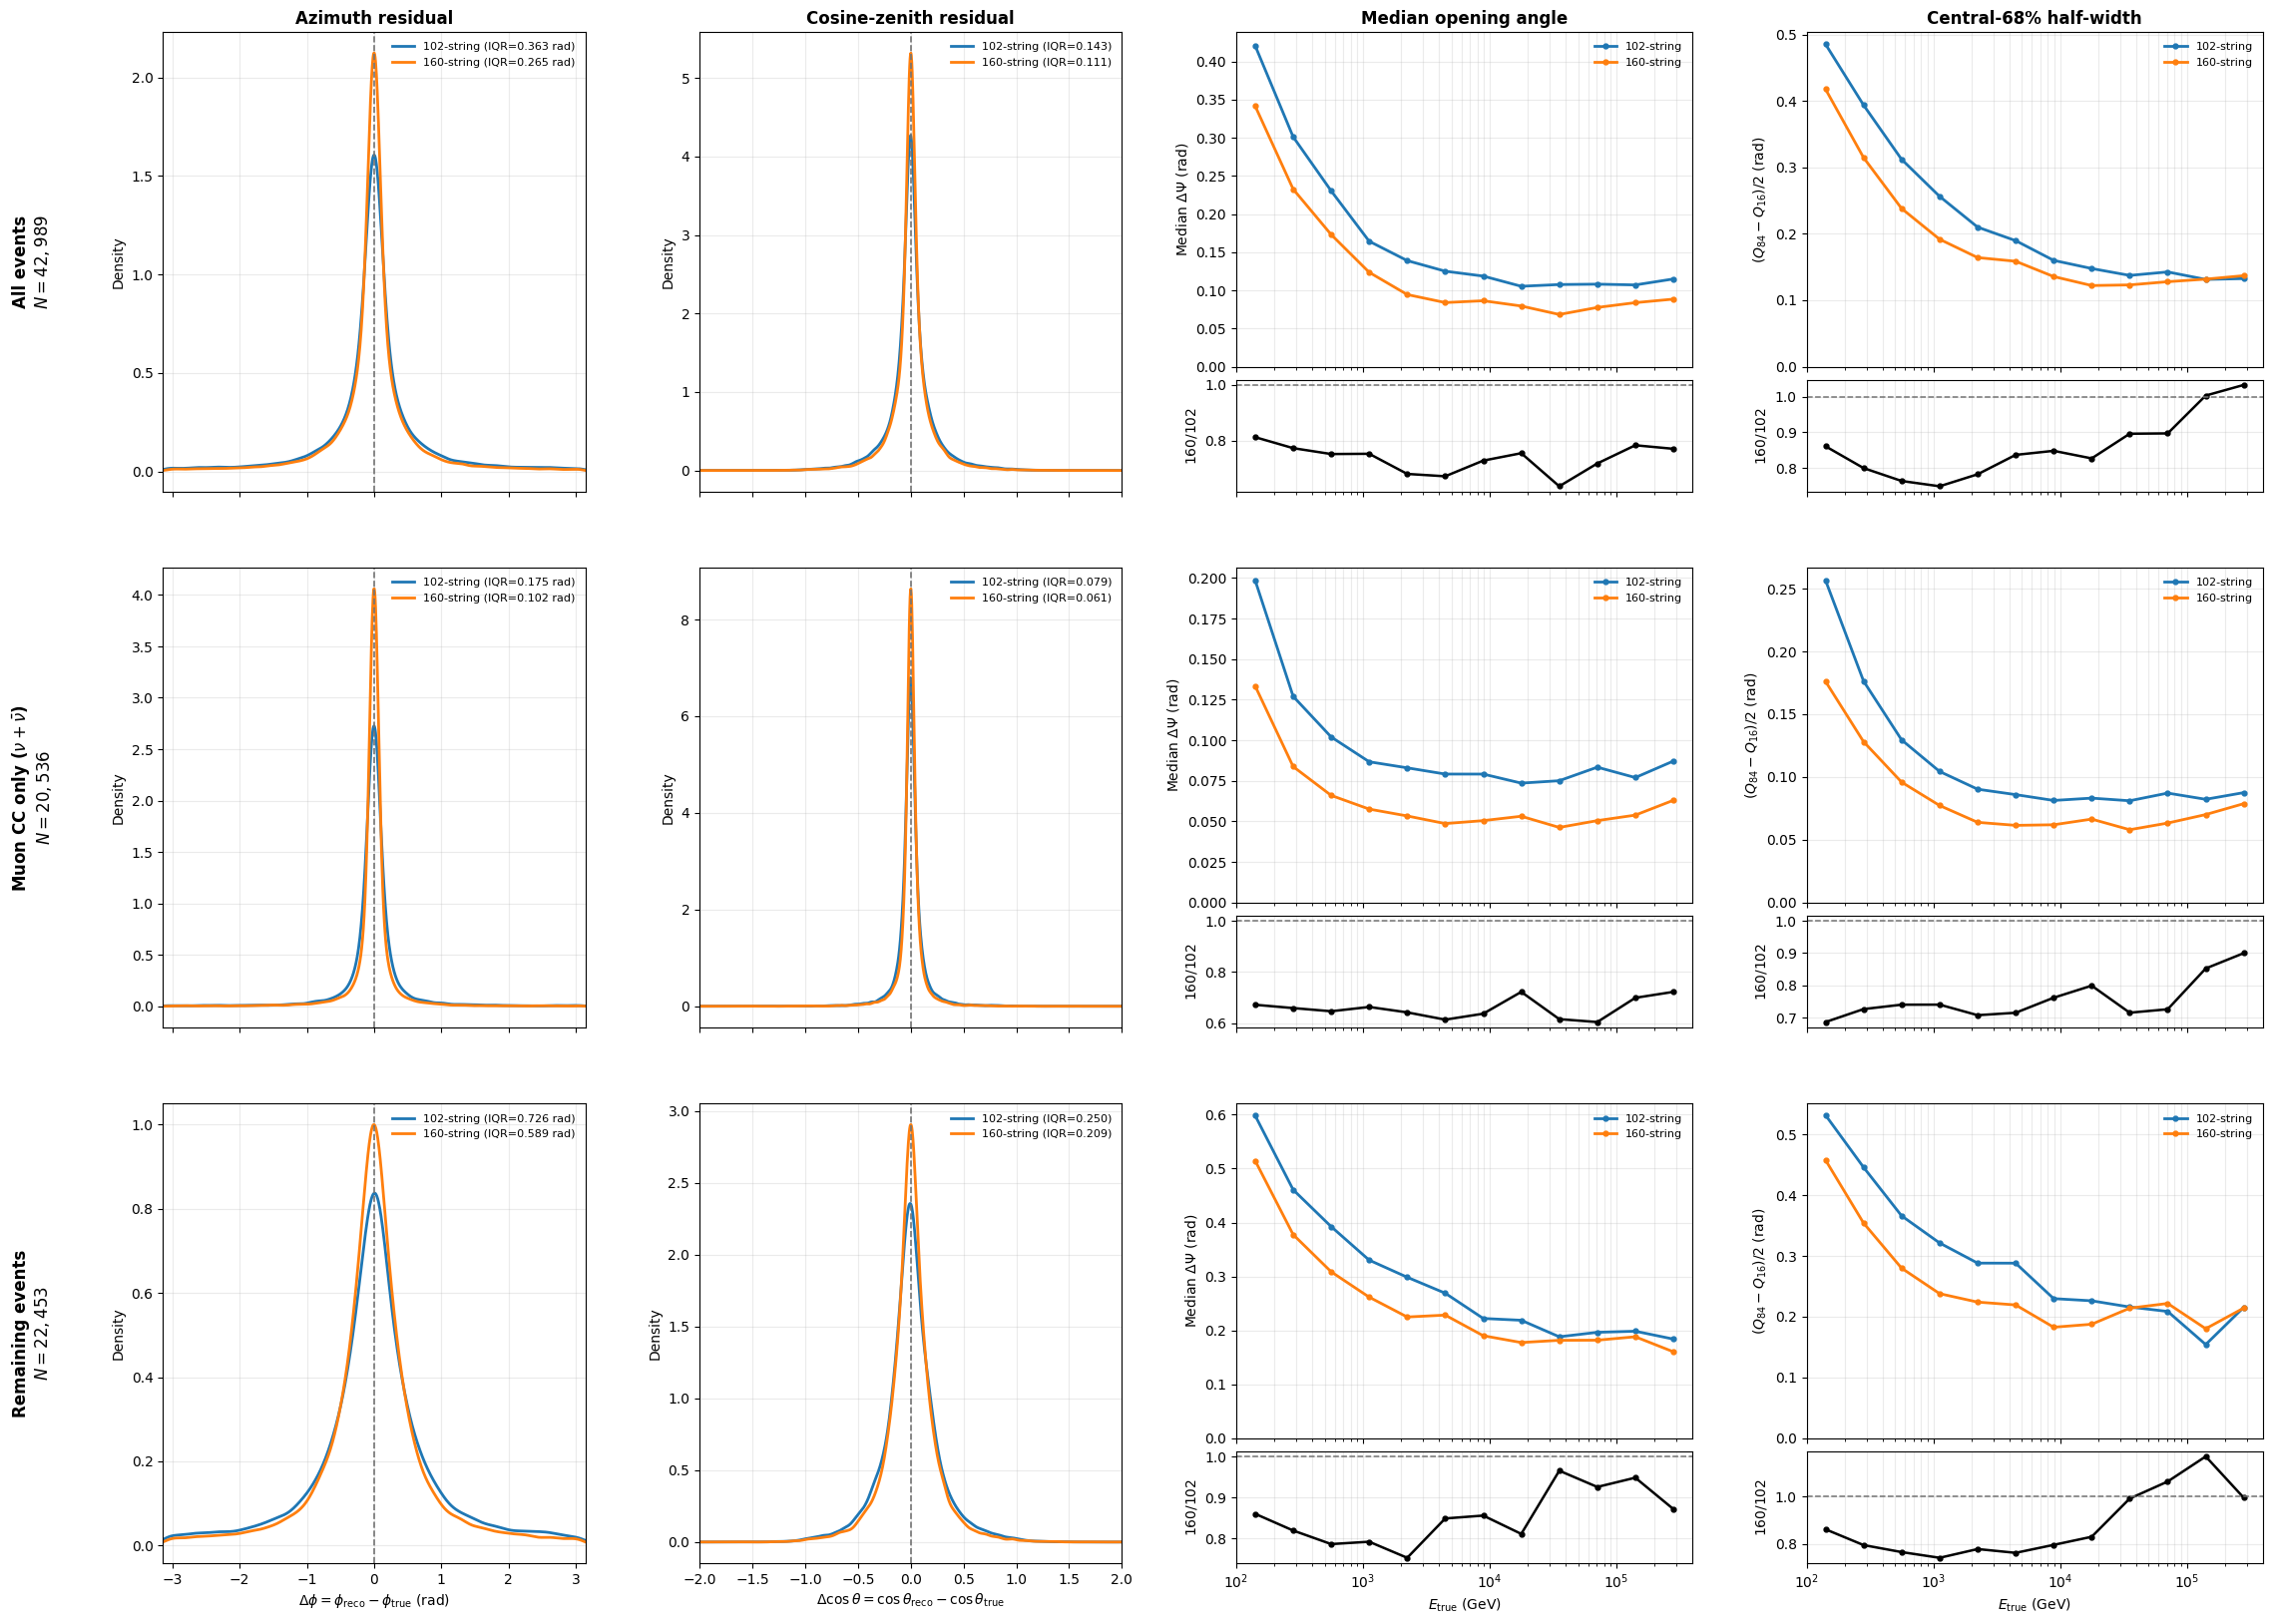

In [11]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


detector_colors = {"102": "tab:blue", "160": "tab:orange"}
muon_cc_mask = (
    (router1_predictions["pid"].abs() == 14)
    & (router1_predictions["is_CC"] == 1)
).to_numpy()

category_rows = [
    ("All events", np.ones(len(router1_predictions), dtype=bool)),
    (r"Muon CC only ($\nu+\bar{\nu}$)", muon_cc_mask),
    ("Remaining events", ~muon_cc_mask),
]

true_azimuth = router1_predictions["true_azimuth_radian"].to_numpy()
true_zenith = router1_predictions["true_zenith_radian"].to_numpy()
true_energy = router1_predictions["true_energy"].to_numpy(dtype=float)
azimuth_grid = np.linspace(-np.pi, np.pi, 1000)
cosine_zenith_grid = np.linspace(-2.0, 2.0, 1000)
energy_bin_edges = np.logspace(2.0, 5.6, 13)
energy_bin_centers = np.sqrt(
    energy_bin_edges[:-1] * energy_bin_edges[1:]
)

# Store the residuals once; the category masks are applied below.
for detector in detector_strings:
    predicted_azimuth = router1_predictions[
        f"{detector}_pred_azimuth_radian"
    ].to_numpy()
    router1_predictions[f"{detector}_azimuth_residual_radian"] = np.arctan2(
        np.sin(predicted_azimuth - true_azimuth),
        np.cos(predicted_azimuth - true_azimuth),
    )

    predicted_zenith = router1_predictions[
        f"{detector}_pred_zenith_radian"
    ].to_numpy()
    router1_predictions[f"{detector}_cosine_zenith_residual"] = (
        np.cos(predicted_zenith) - np.cos(true_zenith)
    )

figure = plt.figure(figsize=(23.0, 17.0))
outer_grid = figure.add_gridspec(
    3 * len(category_rows),
    4,
    width_ratios=[1.0, 1.0, 1.08, 1.08],
    height_ratios=[3.0, 1.0, 0.45] * len(category_rows),
    hspace=0.08,
    wspace=0.26,
)

for row_index, (category_label, category_mask) in enumerate(category_rows):
    category_mask = np.asarray(category_mask, dtype=bool)
    main_row = 3 * row_index
    ratio_row = main_row + 1
    azimuth_axis = figure.add_subplot(
        outer_grid[main_row : ratio_row + 1, 0]
    )
    cosine_zenith_axis = figure.add_subplot(
        outer_grid[main_row : ratio_row + 1, 1]
    )
    median_axis = figure.add_subplot(outer_grid[main_row, 2])
    median_ratio_axis = figure.add_subplot(
        outer_grid[ratio_row, 2], sharex=median_axis
    )
    half_width_axis = figure.add_subplot(outer_grid[main_row, 3])
    half_width_ratio_axis = figure.add_subplot(
        outer_grid[ratio_row, 3], sharex=half_width_axis
    )

    median_by_detector = {}
    half_width_by_detector = {}

    for detector in detector_strings:
        azimuth_residual = router1_predictions[
            f"{detector}_azimuth_residual_radian"
        ].to_numpy()
        selected_azimuth = azimuth_residual[
            category_mask & np.isfinite(azimuth_residual)
        ]
        if selected_azimuth.size >= 2 and np.ptp(selected_azimuth) > 0:
            azimuth_density = gaussian_kde(selected_azimuth)(azimuth_grid)
            q25, q75 = np.quantile(selected_azimuth, [0.25, 0.75])
            azimuth_axis.plot(
                azimuth_grid,
                azimuth_density,
                color=detector_colors[detector],
                linewidth=2.0,
                label=f"{detector}-string (IQR={q75 - q25:.3f} rad)",
            )

        cosine_residual = router1_predictions[
            f"{detector}_cosine_zenith_residual"
        ].to_numpy()
        selected_cosine = cosine_residual[
            category_mask & np.isfinite(cosine_residual)
        ]
        if selected_cosine.size >= 2 and np.ptp(selected_cosine) > 0:
            cosine_density = gaussian_kde(selected_cosine)(
                cosine_zenith_grid
            )
            q25, q75 = np.quantile(selected_cosine, [0.25, 0.75])
            cosine_zenith_axis.plot(
                cosine_zenith_grid,
                cosine_density,
                color=detector_colors[detector],
                linewidth=2.0,
                label=f"{detector}-string (IQR={q75 - q25:.3f})",
            )

        opening_angle_radian = np.radians(
            router1_predictions[f"{detector}_opening_angle"].to_numpy(
                dtype=float
            )
        )
        medians = []
        half_widths = []

        for lower_edge, upper_edge in zip(
            energy_bin_edges[:-1], energy_bin_edges[1:]
        ):
            valid = (
                category_mask
                & (true_energy >= lower_edge)
                & (true_energy < upper_edge)
                & np.isfinite(opening_angle_radian)
            )
            if np.any(valid):
                selected_angles = opening_angle_radian[valid]
                medians.append(np.median(selected_angles))
                q16, q84 = np.quantile(selected_angles, [0.16, 0.84])
                half_widths.append(0.5 * (q84 - q16))
            else:
                medians.append(np.nan)
                half_widths.append(np.nan)

        medians = np.asarray(medians)
        half_widths = np.asarray(half_widths)
        median_by_detector[detector] = medians
        half_width_by_detector[detector] = half_widths

        median_axis.plot(
            energy_bin_centers,
            medians,
            color=detector_colors[detector],
            linewidth=2.0,
            marker="o",
            markersize=3.5,
            label=f"{detector}-string",
        )
        half_width_axis.plot(
            energy_bin_centers,
            half_widths,
            color=detector_colors[detector],
            linewidth=2.0,
            marker="o",
            markersize=3.5,
            label=f"{detector}-string",
        )

    median_ratio = np.divide(
        median_by_detector["160"],
        median_by_detector["102"],
        out=np.full_like(median_by_detector["160"], np.nan),
        where=median_by_detector["102"] > 0,
    )
    half_width_ratio = np.divide(
        half_width_by_detector["160"],
        half_width_by_detector["102"],
        out=np.full_like(half_width_by_detector["160"], np.nan),
        where=half_width_by_detector["102"] > 0,
    )

    median_ratio_axis.plot(
        energy_bin_centers,
        median_ratio,
        color="black",
        linewidth=1.8,
        marker="o",
        markersize=3.5,
    )
    half_width_ratio_axis.plot(
        energy_bin_centers,
        half_width_ratio,
        color="black",
        linewidth=1.8,
        marker="o",
        markersize=3.5,
    )

    azimuth_axis.axvline(
        0.0, color="0.45", linestyle="--", linewidth=1.2
    )
    cosine_zenith_axis.axvline(
        0.0, color="0.45", linestyle="--", linewidth=1.2
    )
    median_ratio_axis.axhline(
        1.0, color="0.45", linestyle="--", linewidth=1.1
    )
    half_width_ratio_axis.axhline(
        1.0, color="0.45", linestyle="--", linewidth=1.1
    )

    azimuth_axis.set_xlim(-np.pi, np.pi)
    cosine_zenith_axis.set_xlim(-2.0, 2.0)
    median_axis.set_ylim(bottom=0.0)
    half_width_axis.set_ylim(bottom=0.0)

    for energy_axis in (
        median_ratio_axis,
        half_width_ratio_axis,
    ):
        energy_axis.set_xscale("log")
        energy_axis.set_xlim(energy_bin_edges[0], energy_bin_edges[-1])
        energy_axis.set_ylabel(r"$160/102$")
        energy_axis.grid(alpha=0.25, which="both")

    azimuth_axis.set_ylabel("Density")
    cosine_zenith_axis.set_ylabel("Density")
    median_axis.set_ylabel(r"Median $\Delta\Psi$ (rad)")
    half_width_axis.set_ylabel(r"$(Q_{84}-Q_{16})/2$ (rad)")

    for main_axis in (
        azimuth_axis,
        cosine_zenith_axis,
        median_axis,
        half_width_axis,
    ):
        main_axis.grid(alpha=0.25, which="both")
        main_axis.legend(frameon=False, fontsize=8)

    azimuth_axis.annotate(
        f"{category_label}\n$N={category_mask.sum():,}$",
        xy=(-0.31, 0.5),
        xycoords="axes fraction",
        ha="center",
        va="center",
        rotation=90,
        fontsize=12,
        fontweight="bold",
    )

    if row_index == 0:
        azimuth_axis.set_title("Azimuth residual", fontweight="bold")
        cosine_zenith_axis.set_title(
            "Cosine-zenith residual", fontweight="bold"
        )
        median_axis.set_title(
            "Median opening angle", fontweight="bold"
        )
        half_width_axis.set_title(
            "Central-68% half-width", fontweight="bold"
        )

    if row_index == len(category_rows) - 1:
        azimuth_axis.set_xlabel(
            r"$\Delta\phi=\phi_{\mathrm{reco}}"
            r"-\phi_{\mathrm{true}}$ (rad)"
        )
        cosine_zenith_axis.set_xlabel(
            r"$\Delta\cos\theta=\cos\theta_{\mathrm{reco}}"
            r"-\cos\theta_{\mathrm{true}}$"
        )
        median_ratio_axis.set_xlabel(r"$E_{\mathrm{true}}$ (GeV)")
        half_width_ratio_axis.set_xlabel(r"$E_{\mathrm{true}}$ (GeV)")
    else:
        azimuth_axis.tick_params(labelbottom=False)
        cosine_zenith_axis.tick_params(labelbottom=False)
        median_ratio_axis.tick_params(labelbottom=False)
        half_width_ratio_axis.tick_params(labelbottom=False)

    median_axis.tick_params(labelbottom=False)
    half_width_axis.tick_params(labelbottom=False)

figure.subplots_adjust(
    left=0.075, right=0.99, bottom=0.04, top=0.98
)
plt.show()